In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = os.path.abspath("..")
FIG = os.path.join(BASE, "outputs", "figures")
PROC = os.path.join(BASE, "data", "processed")
RAW = os.path.join(BASE, "data", "raw")
os.makedirs(FIG, exist_ok=True)

print(BASE)
print(os.listdir(PROC))

d = pd.read_csv(os.path.join(PROC, "dhaka_clean.csv"), parse_dates=["datetime"])
print(d.shape)

/mnt/g/dhaka-air-quality-analysis
['dhaka_clean.csv']
(28992, 14)


In [23]:
#cell 2
print("Ozone peak hour:", d.groupby("hour")["ozone"].mean().idxmax())
print("PM2.5 lowest hour:", d.groupby("hour")["pm2_5"].mean().idxmin())

Ozone peak hour: 14
PM2.5 lowest hour: 15


In [24]:
d["datetime_local"] = d["datetime"] + pd.Timedelta(hours=6)
d["hour"] = d["datetime_local"].dt.hour
d["month"] = d["datetime_local"].dt.month
d["day_of_week"] = d["datetime_local"].dt.dayofweek

def season(m):
    if m in (12, 1, 2): return "Winter"
    if m in (3, 4, 5): return "Summer"
    if m in (6, 7, 8, 9): return "Monsoon"
    return "Post-monsoon"

d["season"] = d["month"].map(season)

d.to_csv(os.path.join(PROC, "dhaka_clean.csv"), index=False)

print("Ozone peak hour:", d.groupby("hour")["ozone"].mean().idxmax())
print("PM2.5 lowest hour:", d.groupby("hour")["pm2_5"].mean().idxmin())

Ozone peak hour: 14
PM2.5 lowest hour: 15


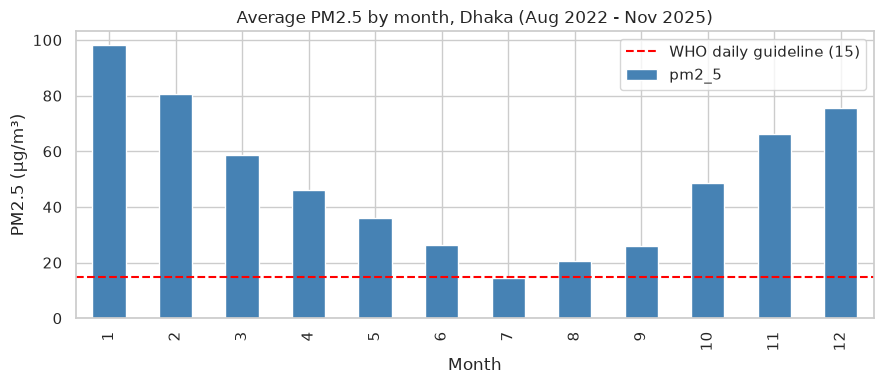

In [25]:
#cell 3
monthly = d.groupby("month")["pm2_5"].mean()
ax = monthly.plot(kind="bar", color="steelblue", figsize=(9, 4))
ax.set_title("Average PM2.5 by month, Dhaka (Aug 2022 - Nov 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.axhline(15, color="red", ls="--", label="WHO daily guideline (15)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "pm25_by_month.png"), dpi=150)
plt.show()

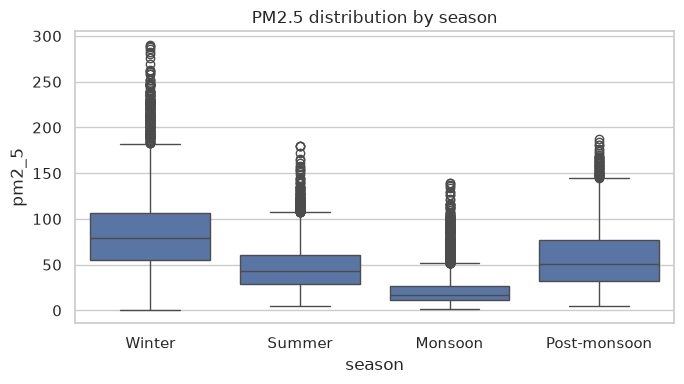

In [26]:
#cell 4
order = ["Winter", "Summer", "Monsoon", "Post-monsoon"]
plt.figure(figsize=(7, 4))
sns.boxplot(data=d, x="season", y="pm2_5", order=order)
plt.title("PM2.5 distribution by season")
plt.tight_layout()
plt.savefig("../outputs/figures/pm25_by_season.png", dpi=150)
plt.show()

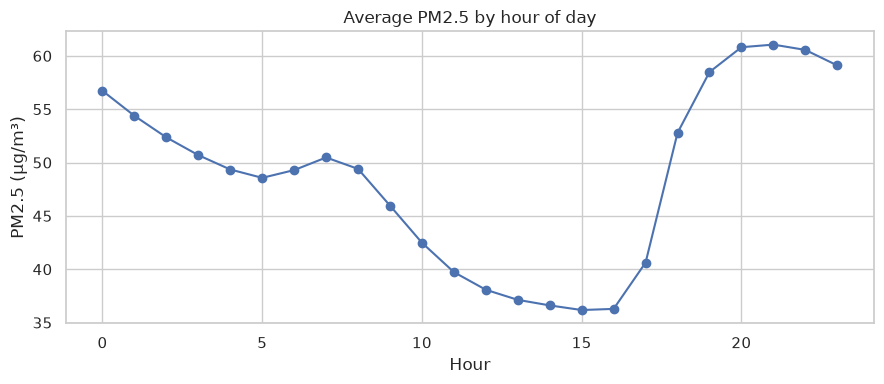

In [27]:
#cell 5
hourly = d.groupby("hour")["pm2_5"].mean()
plt.figure(figsize=(9, 4))
hourly.plot(marker="o")
plt.title("Average PM2.5 by hour of day")
plt.xlabel("Hour"); plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.savefig("../outputs/figures/pm25_by_hour.png", dpi=150)
plt.show()

In [28]:
daily = d.set_index("datetime_local")["pm2_5"].resample("D").mean()
print("Days:", len(daily))
print("Days above WHO guideline (15):", round((daily > 15).mean() * 100, 1), "%")
print("Days above 'Unhealthy' (55.5):", round((daily > 55.5).mean() * 100, 1), "%")

Days: 1209
Days above WHO guideline (15): 84.5 %
Days above 'Unhealthy' (55.5): 38.0 %


In [29]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 23.7104, "longitude": 90.4074,
    "start_date": "2022-08-04", "end_date": "2025-11-23",
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "GMT",
}
r = requests.get(url, params=params, timeout=60)
w = pd.DataFrame(r.json()["hourly"]).rename(columns={"time": "datetime"})
w["datetime"] = pd.to_datetime(w["datetime"])
w.to_csv("../data/raw/weather_dhaka.csv", index=False)
print(w.shape)
w.head()

(28992, 5)


,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2022-08-04 00:00:00,26.7,91,0.0,10.4
1,2022-08-04 01:00:00,27.7,86,0.0,13.2
2,2022-08-04 02:00:00,28.4,82,0.2,15.3
3,2022-08-04 03:00:00,29.3,79,0.0,13.7
4,2022-08-04 04:00:00,30.3,74,0.1,13.2
